Choosing from all possible events


X shape is: (576, 22, 1001)
Label shape is: (576,)
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using EMPIRICAL
Done.
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Estimating class=tongue covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using EMPIRICAL
Done.
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
Estimating class=tongue covariance using EMPIRIC

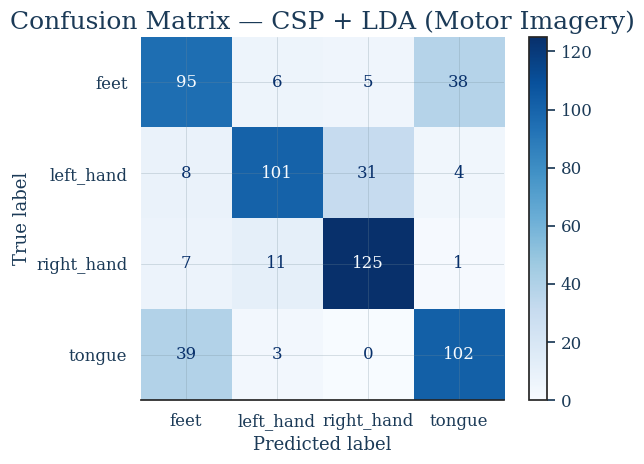

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from mne.decoding import CSP
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

# --- Data ---
dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=32)
X, y, _ = paradigm.get_data(dataset, subjects=[1])
print(f'X shape is: {X.shape}')
print(f'Label shape is: {y.shape}')

# --- Pipeline: CSP + LDA ---
pipeline = Pipeline([
    ('csp', CSP(n_components=4, reg=None, log=True)),
    ('lda', LDA())
])

# ---  Evaluation by Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, X, y, cv=cv)

# ---  Evaluation Criteria ---
print(f"Accuracy  : {accuracy_score(y, y_pred):.4f}")
print(f"Precision : {precision_score(y, y_pred, average='macro'):.4f}")
print(f"Recall    : {recall_score(y, y_pred, average='macro'):.4f}")
print(f"F1-Score  : {f1_score(y, y_pred, average='macro'):.4f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — CSP + LDA (Motor Imagery)")
plt.tight_layout()
plt.show()
